# Flight Booking Analytics

## Data Engineering Project

This notebook presents business insights generated from the Gold layer of the flight booking data warehouse.

The data warehouse follows the Medallion Architecture:

Bronze → Silver → Gold

The Gold layer contains cleaned and aggregated business-ready data used for analytics.

# Data Architecture

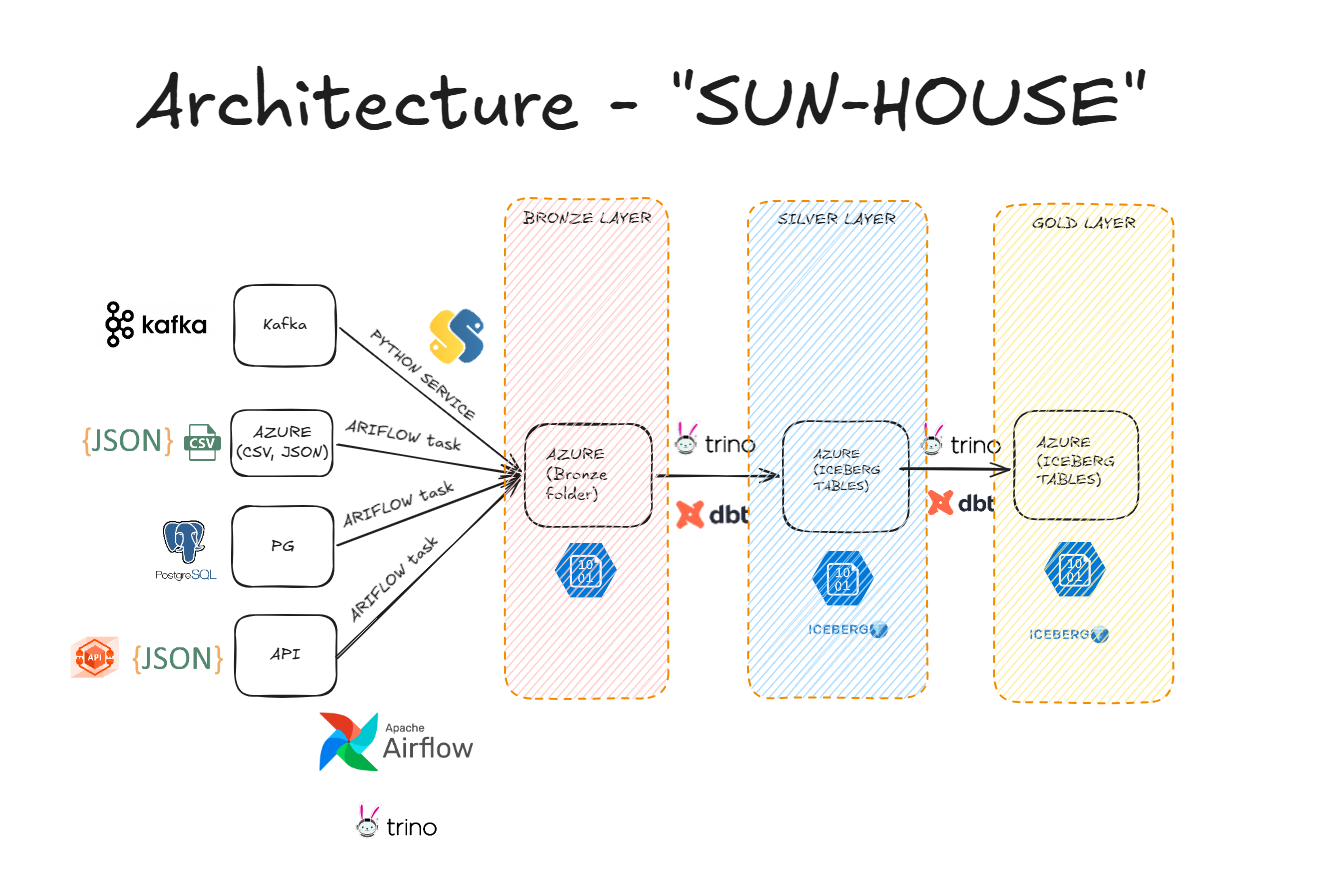

In [31]:
from IPython.display import Image

Image("./architecture.png")

# Entity Relationship Diagram

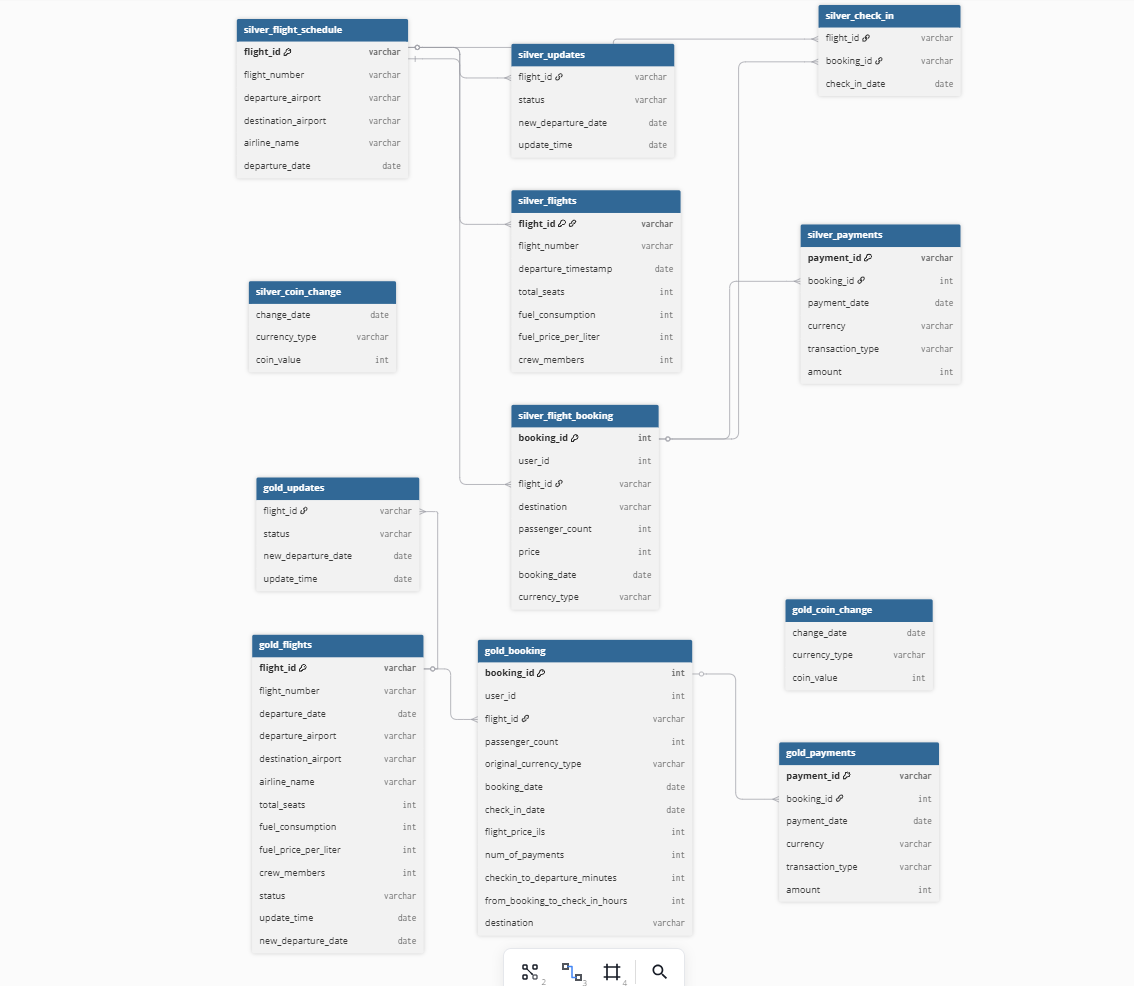

In [32]:
Image("./FINAL_ERD.png")

# Connect to Trino

In [33]:
!pip install trino pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [34]:
import trino
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
conn = trino.dbapi.connect(
    host="trino.de.bsmch.net",
    port=80,
    user="admin",
    catalog="iceberg",
    schema="sunhouse"
)

In [36]:
def run_query(sql):
    cur = conn.cursor()
    cur.execute(sql)

    rows = cur.fetchall()

    columns = [c[0] for c in cur.description]

    return pd.DataFrame(rows, columns=columns)

# Gold Bookings Preview

In [37]:
df = run_query("""
SELECT *
FROM gold_booking
LIMIT 10
""")

df

,booking_id,user_id,flight_id,passenger_count,original_currency_type,booking_date,check_in_date,flight_price_ils,num_of_payments,checkin_to_departure_minutes,from_booking_to_check_in_hours,destination
0,25293,465109,6a0baf149b3de3551b66be632d7a8adc,2,ILS,2026-05-01 00:28:27,2026-05-01 01:41:00,843.0100000,1,514,1,PRAGUE
1,35581,166110,5692161514bda45714513a76b7c106ec,1,USD,2026-05-01 02:05:30,2026-05-01 03:52:00,1547.1800000,1,263,1,TEL AVIV
2,25988,569236,456a51a28683249fa8059f9c1e1670b8,5,USD,2026-05-01 11:41:54,2026-05-01 17:01:00,825.0600000,1,1394,5,TEL AVIV
3,55128,506288,14ec7401c84522d8ce680428a21587e4,5,ILS,2026-05-01 01:56:33,2026-05-01 07:05:00,3369.7000000,1,955,5,TEL AVIV
4,20673,166930,bb8a7c3080532238d5f88186c06623ec,3,ILS,2026-05-01 06:45:32,2026-05-01 07:20:00,5269.4900000,1,880,0,NEW YORK
5,21955,834450,7f5d379fb3b94b5523dd522f5b9d5b74,6,EUR,2026-05-01 05:59:59,2026-05-01 07:34:00,9116.7500000,1,1376,1,TEL AVIV
6,33389,982554,c0d8f243ee9efdc3ea88a11e9524801d,1,USD,2026-05-01 07:57:31,2026-05-01 09:48:00,167.4400000,1,492,1,TEL AVIV
7,33385,314954,c0d8f243ee9efdc3ea88a11e9524801d,6,USD,2026-05-01 07:35:44,2026-05-01 09:55:00,1129.8100000,1,485,2,TEL AVIV
8,66522,139885,1adf65ed26eaf4508cb5f738d6669800,3,EUR,2026-05-01 05:56:36,2026-05-01 09:56:00,1486.4100000,1,199,3,ZURICH
9,49343,495025,34edba0e601ed3721fba625b57729580,1,USD,2026-05-01 06:57:41,2026-05-01 10:19:00,414.9400000,1,416,3,TEL AVIV


# Insight 1

## Revenue by Destination

This analysis identifies the destinations generating the highest revenue.

In [38]:
df = run_query("""
SELECT
    destination,
    SUM(flight_price_ils) AS revenue
FROM gold_booking
GROUP BY destination
ORDER BY revenue DESC
""")

df

,destination,revenue
0,TEL AVIV,1006313.8900000
1,NaN,121917.5100000
2,NEW YORK,79675.9800000
3,UNKNOWN,67244.6300000
4,TOKYO,58804.5100000
5,MADRID,34230.1200000
6,LISBON,30687.8000000
7,PARIS,28513.4100000
8,ZURICH,27337.6500000
9,ROME,25800.3300000


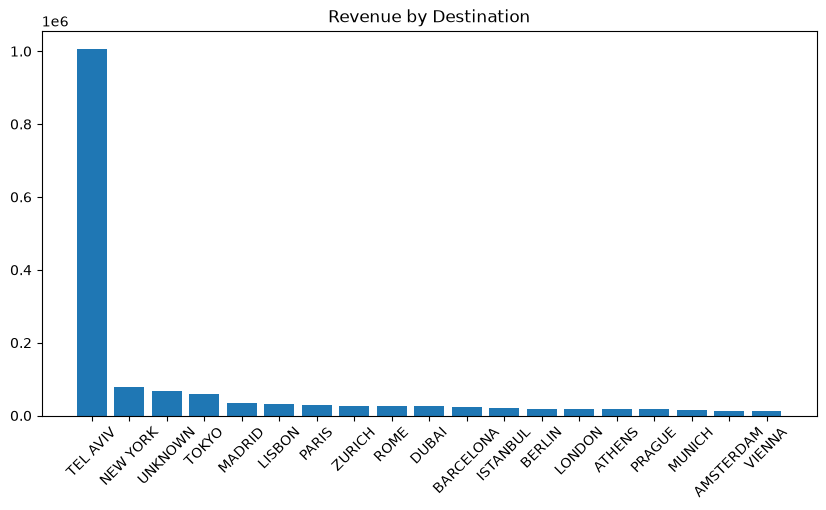

In [39]:
# Create a temporary dataframe without missing destinations or revenues
df_clean = df.dropna(subset=["destination", "revenue"])

plt.figure(figsize=(10,5))      
plt.bar(df_clean["destination"].astype(str), df_clean["revenue"]) 
plt.xticks(rotation=45)
plt.title("Revenue by Destination")

plt.show()

### Interpretation

The chart shows that some destinations generate significantly higher revenue than others.

This information can help identify the company's most profitable routes.

In [40]:
df = run_query("""
SELECT
ROUND(AVG(flight_price_ils),2) avg_price_ils
FROM gold_booking
""")

df

,avg_price_ils
0,2120.8900000


In [41]:
df = run_query("""
SELECT
    ROUND(AVG(from_booking_to_check_in_hours)/24,2) AS avg_days_before_trip
FROM gold_booking
""")

df

,avg_days_before_trip
0,1.28


In [42]:
df = run_query("""
SELECT
    num_of_payments,
    COUNT(*) AS bookings
FROM gold_booking
GROUP BY num_of_payments
ORDER BY num_of_payments
""")

df

,num_of_payments,bookings
0,0,27
1,1,757
